# Federated Medical Image Classification — Result Analysis

**Loads saved results from `results/` and generates publication-quality figures.**

---

Run this notebook **after** results have been pushed to the GitHub repo (or if results are already in `/content/medical_fl_pidl/results/` from notebook 01).

| Section | Contents |
|---|---|
| 1 | Setup |
| 2 | Load all results |
| 3 | Summary tables |
| 4 | Training curves |
| 5 | Loss decomposition |
| 6 | Final performance bars |
| 7 | Calibration (ECE) |
| 8 | Per-class F1 heatmaps |
| 9 | Confusion matrices |
| 10 | Client class distribution |
| 11 | Time analysis |
| 12 | Styled summary table |
| 13 | Download figures |

---
## § 1 — Setup

In [ ]:
# ── new session ───────────────────────────────────
GITHUB_REPO = 'https://github.com/PulockDas/medical_fl_pidl.git'
# ──────────────────────────────────────────────────────────────────────

import os, sys
from pathlib import Path

PROJECT_ROOT = Path('/content/medical_fl_pidl')

if not PROJECT_ROOT.exists():
    os.system(f'git clone {GITHUB_REPO} {PROJECT_ROOT}')
else:
    os.system(f'git -C {PROJECT_ROOT} pull')

sys.path.insert(0, str(PROJECT_ROOT))
RESULTS_ROOT = PROJECT_ROOT / 'results'
FIGURES_DIR  = RESULTS_ROOT / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

!pip install -q seaborn pandas matplotlib scikit-learn

print(f'Results : {RESULTS_ROOT}')
print(f'Figures : {FIGURES_DIR}')


Results : /content/medical_fl_pidl/results
Figures : /content/medical_fl_pidl/results/figures


In [18]:
import json, warnings
from itertools import product
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')

# Publication-quality style
plt.rcParams.update({
    'font.family':   'serif',
    'font.size':     11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'figure.dpi':    150,
    'savefig.dpi':   300,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.constrained_layout.use': True,
})

# Colorblind-friendly palette (Wong 2011)
WONG = ['#E69F00','#56B4E9','#009E73','#F0E442','#0072B2','#D55E00','#CC79A7','#000000']
C_CLIENT  = {3: WONG[1], 4: WONG[2], 5: WONG[5]}
M_CLIENT  = {3: 'o',     4: 's',     5: '^'}
LS_CLIENT = {3: '-',     4: '--',    5: ':'}

SAVE_FMT = 'png'   # change to 'pdf' for camera-ready

def savefig(name):
    p = FIGURES_DIR / f'{name}.{SAVE_FMT}'
    plt.savefig(p, bbox_inches='tight', dpi=300)
    print(f'  Saved: {p.name}')

print('Style loaded.')


Style loaded.


---
## § 2 — Load All Results

In [19]:
DATASETS      = ['brain_tumor_mri', 'colon_cancer_or_pathology', 'covid']
CLIENT_COUNTS = [3, 4, 5]
C_DS = {ds: WONG[i] for i, ds in enumerate(DATASETS)}

def _json(p): return json.load(open(p)) if Path(p).exists() else None
def _csv(p):  return pd.read_csv(p) if Path(p).exists() else None
def _exp(ds, nc): return RESULTS_ROOT / ds / f'{nc}_clients'

# ── Auto-generate fl_summary.json from fl_rounds.csv if missing ───────
def _build_summary_from_csv(ds, nc):
    folder   = _exp(ds, nc)
    csv_path = folder / 'fl_rounds.csv'
    jsonl_path = folder / 'round_metrics.jsonl'
    if not csv_path.exists():
        return
    df = pd.read_csv(csv_path)
    df = df[df['round'] > 0].reset_index(drop=True)
    if df.empty:
        return
    last = df.iloc[-1]
    def best(col):
        idx = df[col].idxmax()
        return float(df[col][idx]), int(df['round'][idx])
    best_acc,   best_acc_rnd   = best('global_test_acc')
    best_bal,   best_bal_rnd   = best('balanced_accuracy')
    best_f1,    best_f1_rnd    = best('f1_macro')
    best_auc,   best_auc_rnd   = best('roc_auc_macro')
    best_prauc, best_prauc_rnd = best('pr_auc_macro')
    secagg_times = []
    if jsonl_path.exists():
        lines = jsonl_path.read_text().strip().splitlines()
        for line in lines[-len(df):]:
            rec = json.loads(line)
            if 'secagg_overhead_sec' in rec:
                secagg_times.append(rec['secagg_overhead_sec'])
    summary = {
        'dataset_name': ds, 'num_clients': nc, 'num_rounds': len(df),
        'best_accuracy': best_acc, 'best_accuracy_round': best_acc_rnd,
        'final_accuracy': float(last['global_test_acc']),
        'best_balanced_accuracy': best_bal, 'best_balanced_accuracy_round': best_bal_rnd,
        'final_balanced_accuracy': float(last['balanced_accuracy']),
        'best_macro_f1': best_f1, 'best_macro_f1_round': best_f1_rnd,
        'final_macro_f1': float(last['f1_macro']),
        'best_roc_auc_macro': best_auc, 'best_roc_auc_macro_round': best_auc_rnd,
        'final_roc_auc_macro': float(last['roc_auc_macro']),
        'best_pr_auc_macro': best_prauc, 'best_pr_auc_macro_round': best_prauc_rnd,
        'final_pr_auc_macro': float(last['pr_auc_macro']),
        'final_ece': float(last['ece']),
        'final_mean_confidence': float(last['mean_confidence']),
        'final_mean_entropy': float(last['mean_entropy']),
        'total_training_time_sec': round(float(df['training_time_sec'].sum()), 2),
        'total_inference_time_sec': round(float(df['inference_time_sec'].sum()), 2),
        'secagg_overhead_per_round_sec': round(sum(secagg_times)/len(secagg_times), 4) if secagg_times else None,
        'secagg_overhead_total_sec': round(sum(secagg_times), 4) if secagg_times else None,
        'final_confusion_matrix': None,
    }
    (folder / 'fl_summary.json').write_text(json.dumps(summary, indent=2))
    print(f'  [auto-gen] fl_summary.json -> {ds}/{nc}_clients')

for ds in DATASETS:
    for nc in CLIENT_COUNTS:
        summary_path = _exp(ds, nc) / 'fl_summary.json'
        csv_path     = _exp(ds, nc) / 'fl_rounds.csv'
        if not summary_path.exists() and csv_path.exists():
            _build_summary_from_csv(ds, nc)

# ── Load experiments ───────────────────────────────────────────────────
summaries, rounds_dfs, clients_dfs, perclass_dfs, evals, ds_sums = \
    {}, {}, {}, {}, {}, {}

found = []
for ds, nc in product(DATASETS, CLIENT_COUNTS):
    d = _exp(ds, nc)
    if not (d / 'fl_summary.json').exists(): continue
    k = (ds, nc)
    summaries[k]   = _json(d / 'fl_summary.json') or {}
    rounds_dfs[k]  = _csv(d / 'fl_rounds.csv')
    clients_dfs[k] = _csv(d / 'fl_clients.csv')
    perclass_dfs[k]= _csv(d / 'per_class_metrics.csv')
    evals[k]       = _json(d / 'fl_eval.json') or []
    ds_sums[k]     = _json(d / 'dataset_summary.json') or {}
    found.append(k)

print(f'Loaded {len(found)} experiments:')
for ds, nc in found:
    r = rounds_dfs.get((ds,nc)); nr = len(r) if r is not None else '?'
    print(f'  {ds}/{nc}c  ({nr} rounds)')


Loaded 0 experiments:


---
## § 2b — Enrich rounds_dfs from round_metrics.jsonl

Backfills `ce_loss`, `reg_loss`, `training_time_sec`, and `secagg_overhead_sec`
from the JSONL files (the CSV has these as 0 because finalize never ran).

In [20]:
def _enrich_from_jsonl(ds, nc):
    """Patch rounds_dfs[(ds,nc)] with training metrics from round_metrics.jsonl."""
    k = (ds, nc)
    df = rounds_dfs.get(k)
    jsonl_path = _exp(ds, nc) / 'round_metrics.jsonl'
    if df is None or not jsonl_path.exists():
        return

    # Parse JSONL — take only the LAST num_rounds entries (most recent run)
    all_lines = [json.loads(l) for l in jsonl_path.read_text().strip().splitlines()]
    num_rounds = len(df[df['round'] > 0])   # exclude round-0 baseline row
    recent = all_lines[-num_rounds:]

    # Build a lookup: server_round -> metrics
    lookup = {r.get('round') or r.get('server_round'): r for r in recent}

    # Patch each training-round row
    for idx, row in df.iterrows():
        rnd = int(row['round'])
        if rnd == 0 or rnd not in lookup:
            continue
        rec = lookup[rnd]
        df.at[idx, 'ce_loss']            = rec.get('train_ce_loss',    0.0)
        df.at[idx, 'reg_loss']           = rec.get('train_pidl_loss',  0.0)
        df.at[idx, 'training_time_sec']  = rec.get('elapsed_seconds',  0.0)
        df.at[idx, 'secagg_overhead_sec']= rec.get('secagg_overhead_sec', 0.0)

    rounds_dfs[k] = df

# Also build a per-experiment secagg summary for the time-analysis section
secagg_summary = {}   # (ds, nc) -> {'per_round': float, 'total': float}

for ds, nc in found:
    _enrich_from_jsonl(ds, nc)
    df = rounds_dfs.get((ds, nc))
    if df is not None and 'secagg_overhead_sec' in df.columns:
        vals = df[df['secagg_overhead_sec'] > 0]['secagg_overhead_sec']
        if len(vals):
            secagg_summary[(ds, nc)] = {
                'per_round': float(vals.mean()),
                'total':     float(vals.sum()),
            }

print('Enriched rounds_dfs with ce_loss / reg_loss / training_time_sec / secagg_overhead_sec')
for (ds, nc), info in secagg_summary.items():
    print(f'  {ds}/{nc}c  secagg per-round={info["per_round"]:.4f}s  total={info["total"]:.4f}s')


Enriched rounds_dfs with ce_loss / reg_loss / training_time_sec / secagg_overhead_sec


---
## § 3 — Summary Tables

In [21]:
rows = []
for (ds, nc), s in summaries.items():
    r = rounds_dfs.get((ds, nc)); last = r.iloc[-1].to_dict() if r is not None and len(r) else {}
    rows.append({
        'dataset': ds, 'num_clients': nc,
        'num_rounds':               s.get('num_rounds',             last.get('round')),
        'final_accuracy':           s.get('final_accuracy',         last.get('global_test_acc')),
        'best_accuracy':            s.get('best_accuracy'),
        'final_balanced_accuracy':  s.get('final_balanced_accuracy',last.get('balanced_accuracy')),
        'best_balanced_accuracy':   s.get('best_balanced_accuracy'),
        'final_macro_f1':           s.get('final_macro_f1',         last.get('f1_macro')),
        'best_macro_f1':            s.get('best_macro_f1'),
        'final_weighted_f1':        last.get('f1_weighted'),
        'final_precision_macro':    last.get('precision_macro'),
        'final_recall_macro':       last.get('recall_macro'),
        'final_specificity_macro':  last.get('specificity_macro'),
        'final_roc_auc_macro':      s.get('final_roc_auc_macro',    last.get('roc_auc_macro')),
        'best_roc_auc_macro':       s.get('best_roc_auc_macro'),
        'final_pr_auc_macro':       s.get('final_pr_auc_macro',     last.get('pr_auc_macro')),
        'final_ece':                s.get('final_ece',              last.get('ece')),
        'final_mean_confidence':    last.get('mean_confidence'),
        'total_training_time_sec':  s.get('total_training_time_sec'),
        'total_inference_time_sec': s.get('total_inference_time_sec'),
    })

master = pd.DataFrame(rows)
master.to_csv(RESULTS_ROOT / 'master_summary.csv', index=False)
print('master_summary.csv saved')
display(master)


master_summary.csv saved


""


In [22]:
# Final comparison table (paper-ready columns)
CMP_COLS = ['dataset','num_clients','best_accuracy','final_balanced_accuracy',
            'best_macro_f1','final_weighted_f1','final_precision_macro',
            'final_recall_macro','final_specificity_macro',
            'final_roc_auc_macro','final_pr_auc_macro','final_ece',
            'total_training_time_sec','total_inference_time_sec']
cmp = master[[c for c in CMP_COLS if c in master.columns]]
cmp.to_csv(RESULTS_ROOT / 'final_comparison_table.csv', index=False)

# Per-class comparison (final round)
pc_rows = []
for (ds, nc), df in perclass_dfs.items():
    if df is None or df.empty: continue
    for _, row in df[df['round'] == df['round'].max()].iterrows():
        pc_rows.append({'dataset': ds, 'num_clients': nc,
                        'class_name': row.get('class_name'),
                        'precision': row.get('precision'),
                        'recall': row.get('recall'),
                        'f1': row.get('f1'), 'support': row.get('support')})
pc = pd.DataFrame(pc_rows)
pc.to_csv(RESULTS_ROOT / 'per_class_comparison.csv', index=False)
print('Tables saved: final_comparison_table.csv, per_class_comparison.csv')


Tables saved: final_comparison_table.csv, per_class_comparison.csv


---
## § 4 — Training Curves

  Saved: 01_training_curves.png


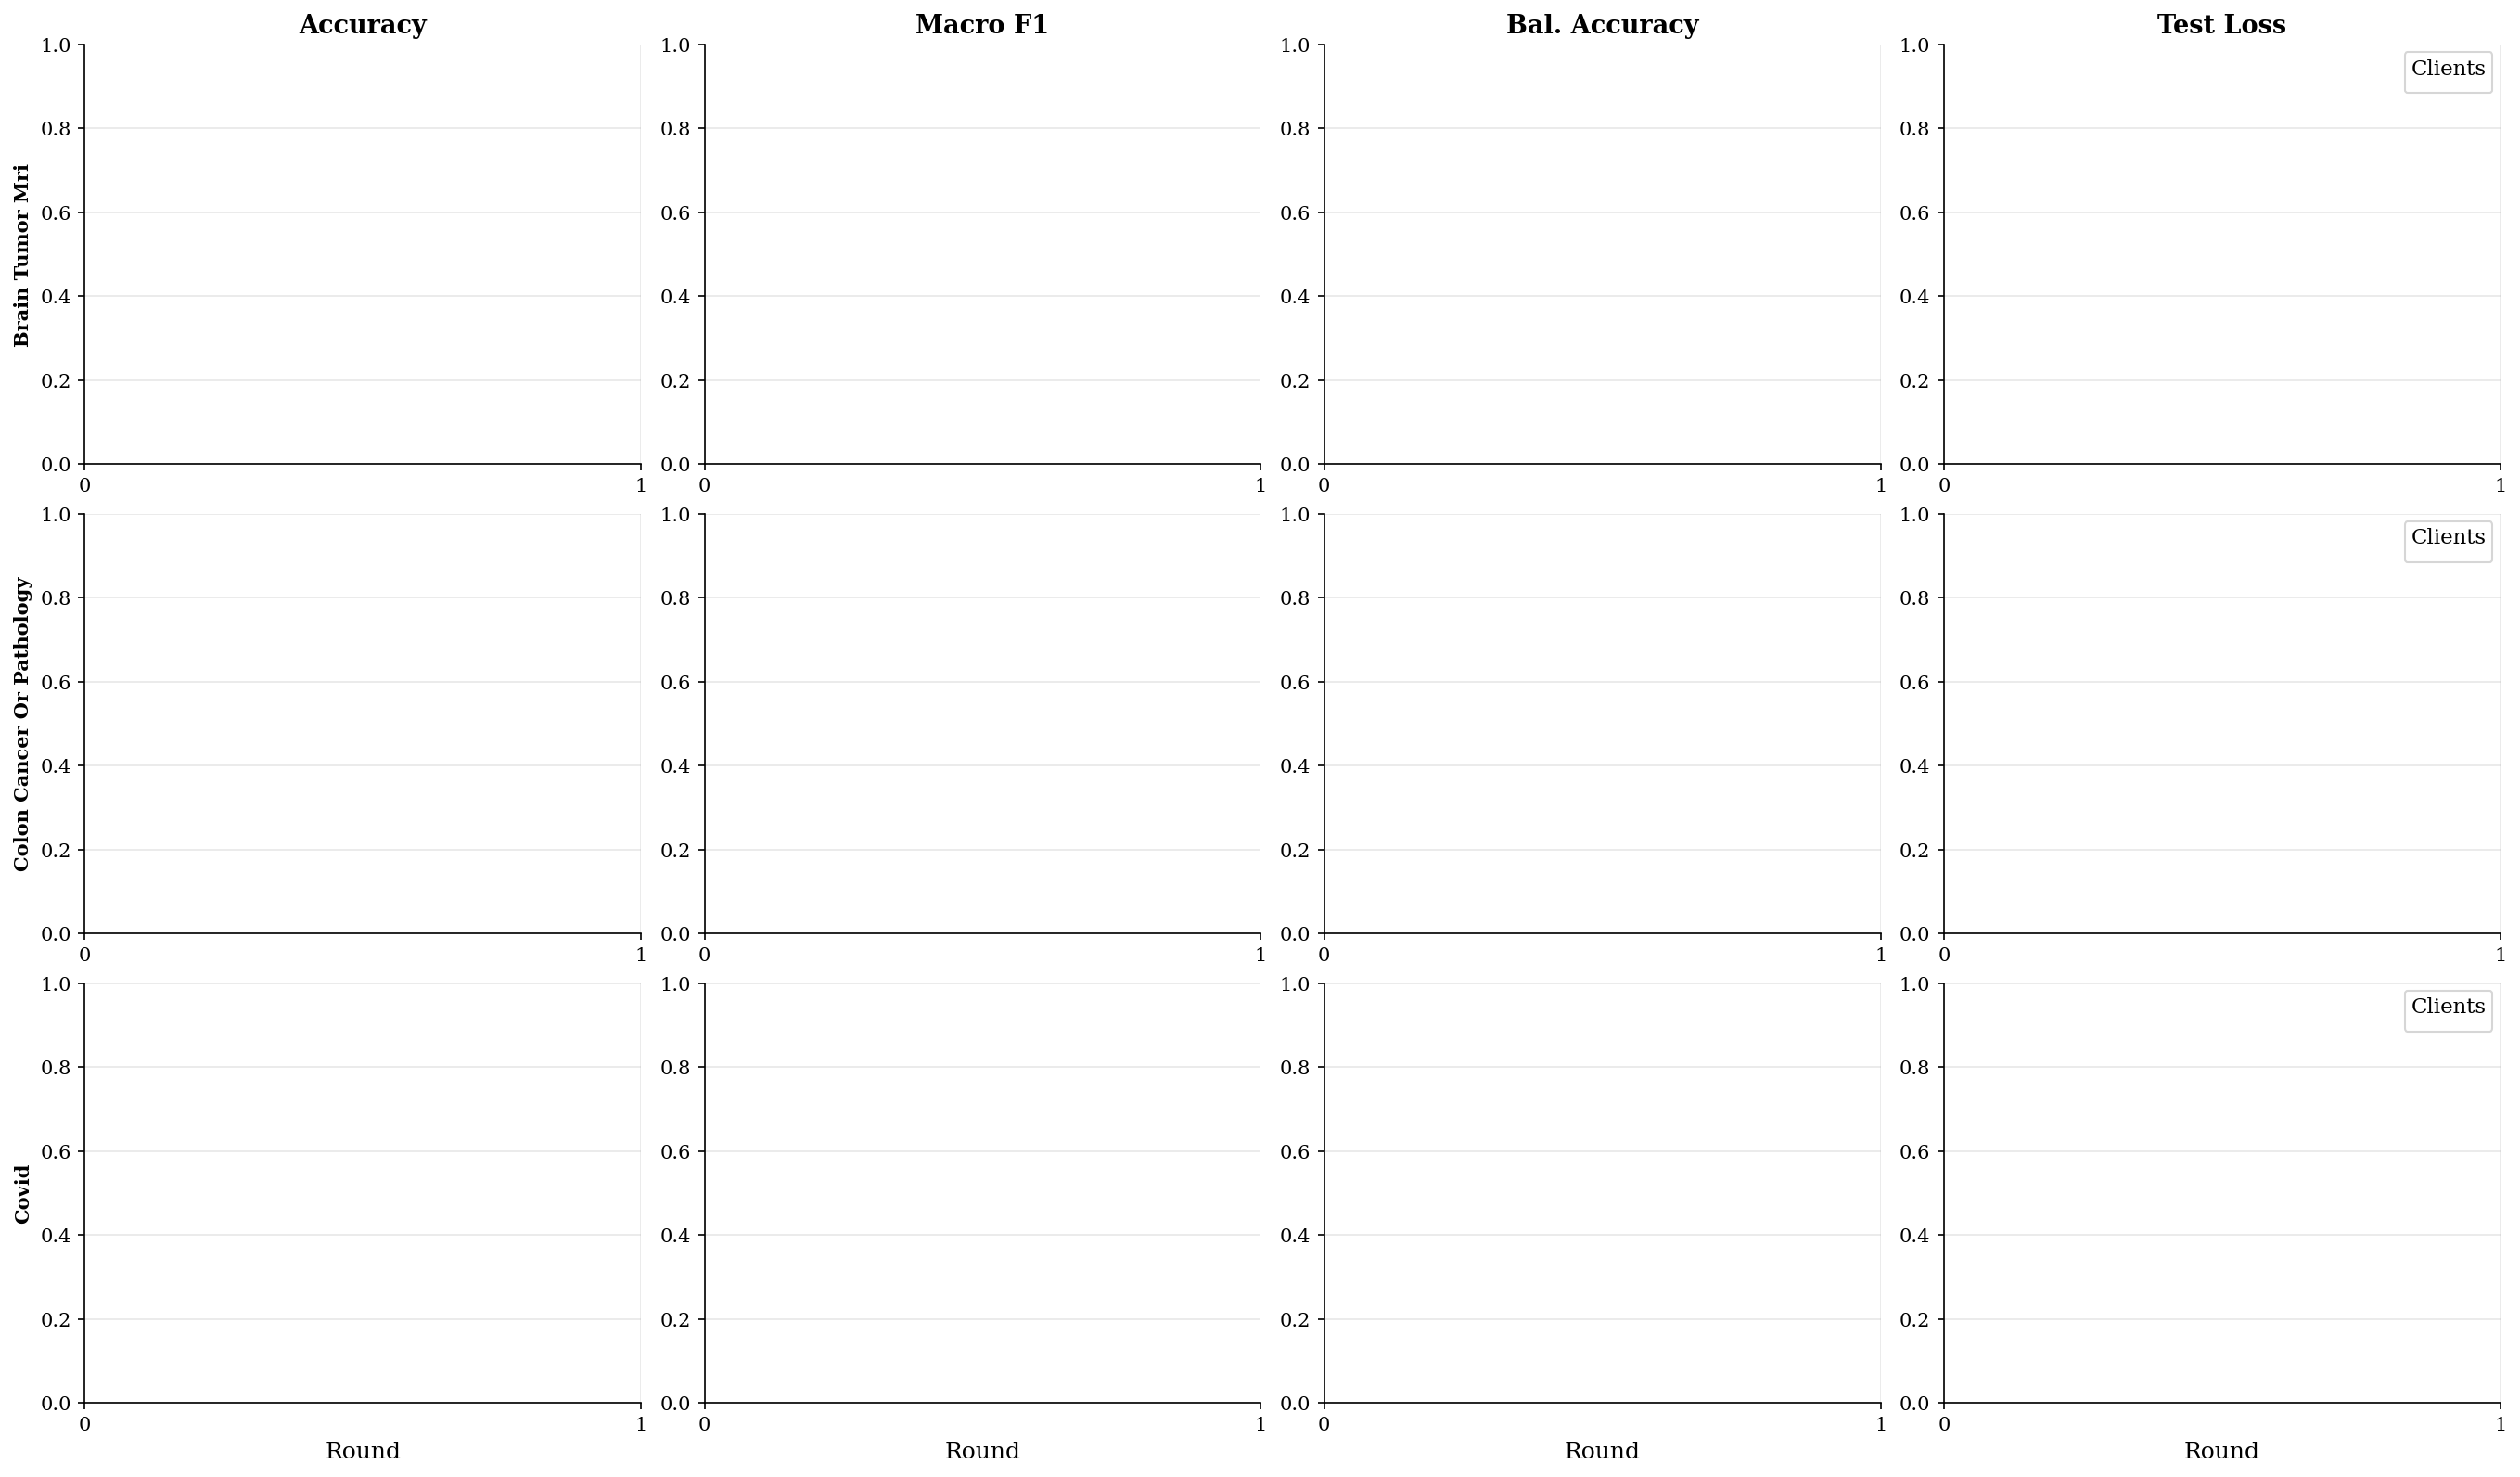

In [23]:
CURVE_METRICS = [
    ('global_test_acc',   'Accuracy',     (0, 1)),
    ('f1_macro',          'Macro F1',     (0, 1)),
    ('balanced_accuracy', 'Bal. Accuracy',(0, 1)),
    ('global_test_loss',  'Test Loss',    None),
]
fig, axes = plt.subplots(len(DATASETS), len(CURVE_METRICS),
                         figsize=(4.5*len(CURVE_METRICS), 3.5*len(DATASETS)),
                         squeeze=False)

for ri, ds in enumerate(DATASETS):
    axes[ri,0].set_ylabel(ds.replace('_',' ').title(), fontweight='bold', fontsize=10)
    for ci, (col, title, ylim) in enumerate(CURVE_METRICS):
        ax = axes[ri, ci]
        for nc in CLIENT_COUNTS:
            df = rounds_dfs.get((ds,nc))
            if df is None or col not in df.columns: continue
            ax.plot(df['round'], df[col], color=C_CLIENT[nc], marker=M_CLIENT[nc],
                    ls=LS_CLIENT[nc], label=f'{nc}c', markersize=4)
        if ri == 0: ax.set_title(title, fontweight='bold')
        if ylim: ax.set_ylim(*ylim)
        ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
        if ri == len(DATASETS)-1: ax.set_xlabel('Round')
        if ci == len(CURVE_METRICS)-1: ax.legend(title='Clients', fontsize=8)

savefig('01_training_curves')
plt.show()


---
## § 5 — Loss Decomposition: CE Loss vs Regularization Loss

  Saved: 02_loss_decomposition.png


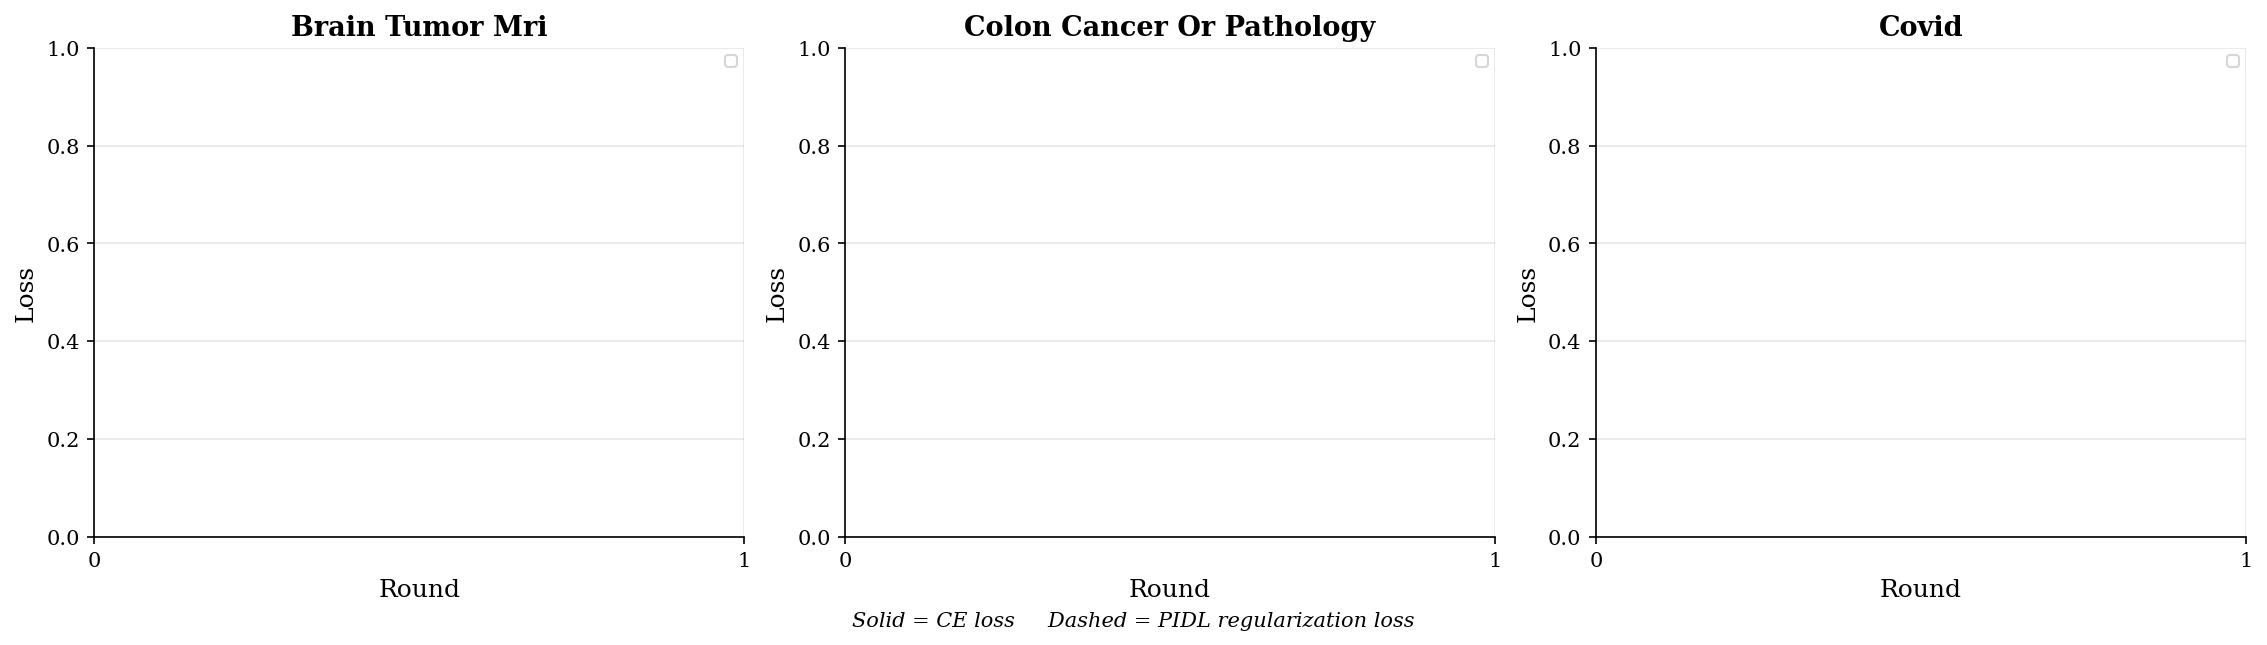

In [24]:
fig, axes = plt.subplots(1, len(DATASETS), figsize=(5*len(DATASETS), 4))
axes = [axes] if len(DATASETS)==1 else list(axes)

for ax, ds in zip(axes, DATASETS):
    for nc in CLIENT_COUNTS:
        df = rounds_dfs.get((ds,nc))
        if df is None: continue
        if 'ce_loss' in df and df['ce_loss'].sum() > 0:
            ax.plot(df['round'], df['ce_loss'], color=C_CLIENT[nc],
                    ls='-', marker=M_CLIENT[nc], label=f'{nc}c CE', markersize=4)
        if 'reg_loss' in df and df['reg_loss'].sum() > 0:
            ax.plot(df['round'], df['reg_loss'], color=C_CLIENT[nc],
                    ls='--', marker=M_CLIENT[nc], label=f'{nc}c Reg', markersize=4, alpha=0.7)
    ax.set_title(ds.replace('_',' ').title(), fontweight='bold')
    ax.set_xlabel('Round'); ax.set_ylabel('Loss')
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.legend(fontsize=7, ncol=2)

fig.text(0.5, -0.03, 'Solid = CE loss     Dashed = PIDL regularization loss',
         ha='center', fontsize=10, style='italic')
savefig('02_loss_decomposition')
plt.show()


---
## § 6 — Final Performance Comparison

  Saved: 03_accuracy_f1_balanced.png


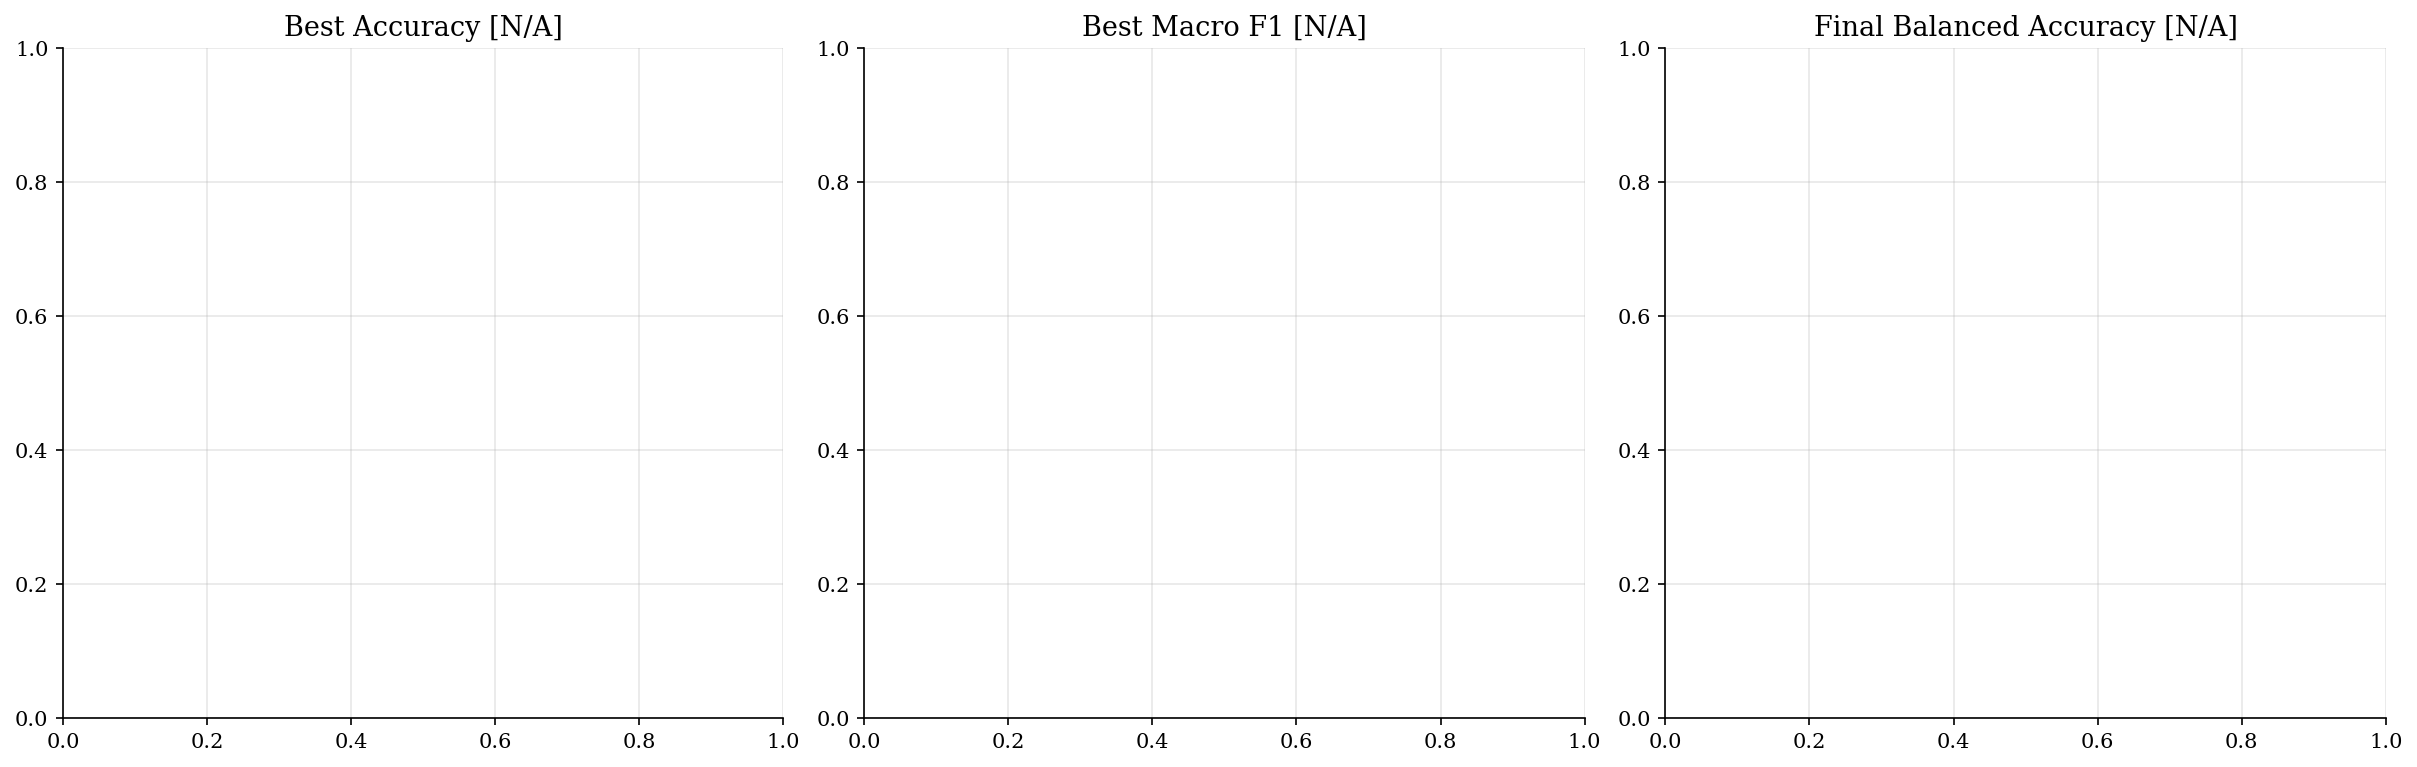

  Saved: 04_precision_recall_auc.png


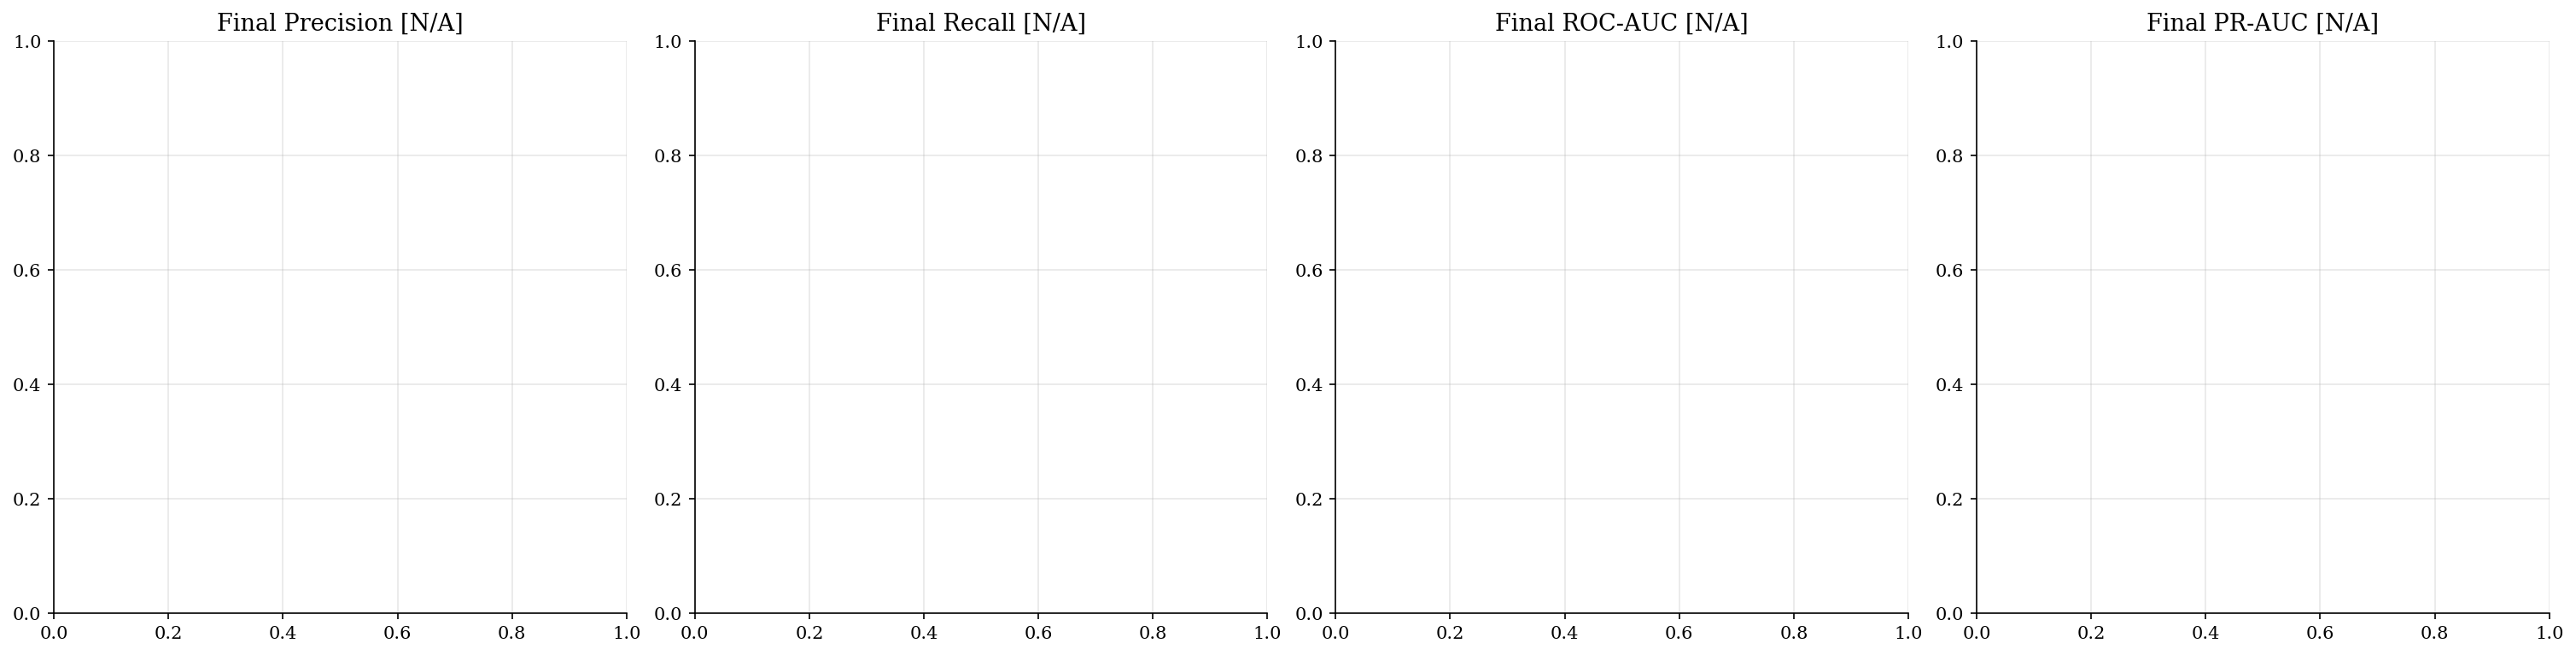

In [25]:
def grouped_bar(df, col, title, ax):
    if col not in df or df[col].isna().all(): ax.set_title(f'{title} [N/A]'); return
    tmp = df[['dataset','num_clients',col]].copy()
    tmp['num_clients'] = tmp['num_clients'].astype(str)+'c'
    piv = tmp.pivot(index='dataset', columns='num_clients', values=col)
    x = np.arange(len(piv)); w = 0.7/len(piv.columns)
    offs = np.linspace(-(len(piv.columns)-1)/2,(len(piv.columns)-1)/2,len(piv.columns))*w
    for nc_str, off in zip(piv.columns, offs):
        nc = int(nc_str[:-1])
        b = ax.bar(x+off, piv[nc_str], w, label=nc_str, color=C_CLIENT.get(nc,'gray'),
                   edgecolor='white', linewidth=0.5, zorder=3)
        ax.bar_label(b, fmt='%.3f', fontsize=7, padding=2)
    ax.set_title(title, fontweight='bold'); ax.set_xticks(x)
    ax.set_xticklabels([d.replace('_','\n') for d in piv.index], fontsize=8)
    ax.set_ylim(0, 1.12); ax.legend(title='Clients', fontsize=8)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
    ax.set_axisbelow(True)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
grouped_bar(master, 'best_accuracy',           'Best Accuracy',          axes[0])
grouped_bar(master, 'best_macro_f1',            'Best Macro F1',           axes[1])
grouped_bar(master, 'final_balanced_accuracy',  'Final Balanced Accuracy', axes[2])
savefig('03_accuracy_f1_balanced')
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (col, title) in zip(axes, [
    ('final_precision_macro','Final Precision'),
    ('final_recall_macro',   'Final Recall'),
    ('final_roc_auc_macro',  'Final ROC-AUC'),
    ('final_pr_auc_macro',   'Final PR-AUC'),
]):
    grouped_bar(master, col, title, ax)
savefig('04_precision_recall_auc')
plt.show()


---
## § 7 — Calibration (ECE)

  Saved: 05_calibration.png


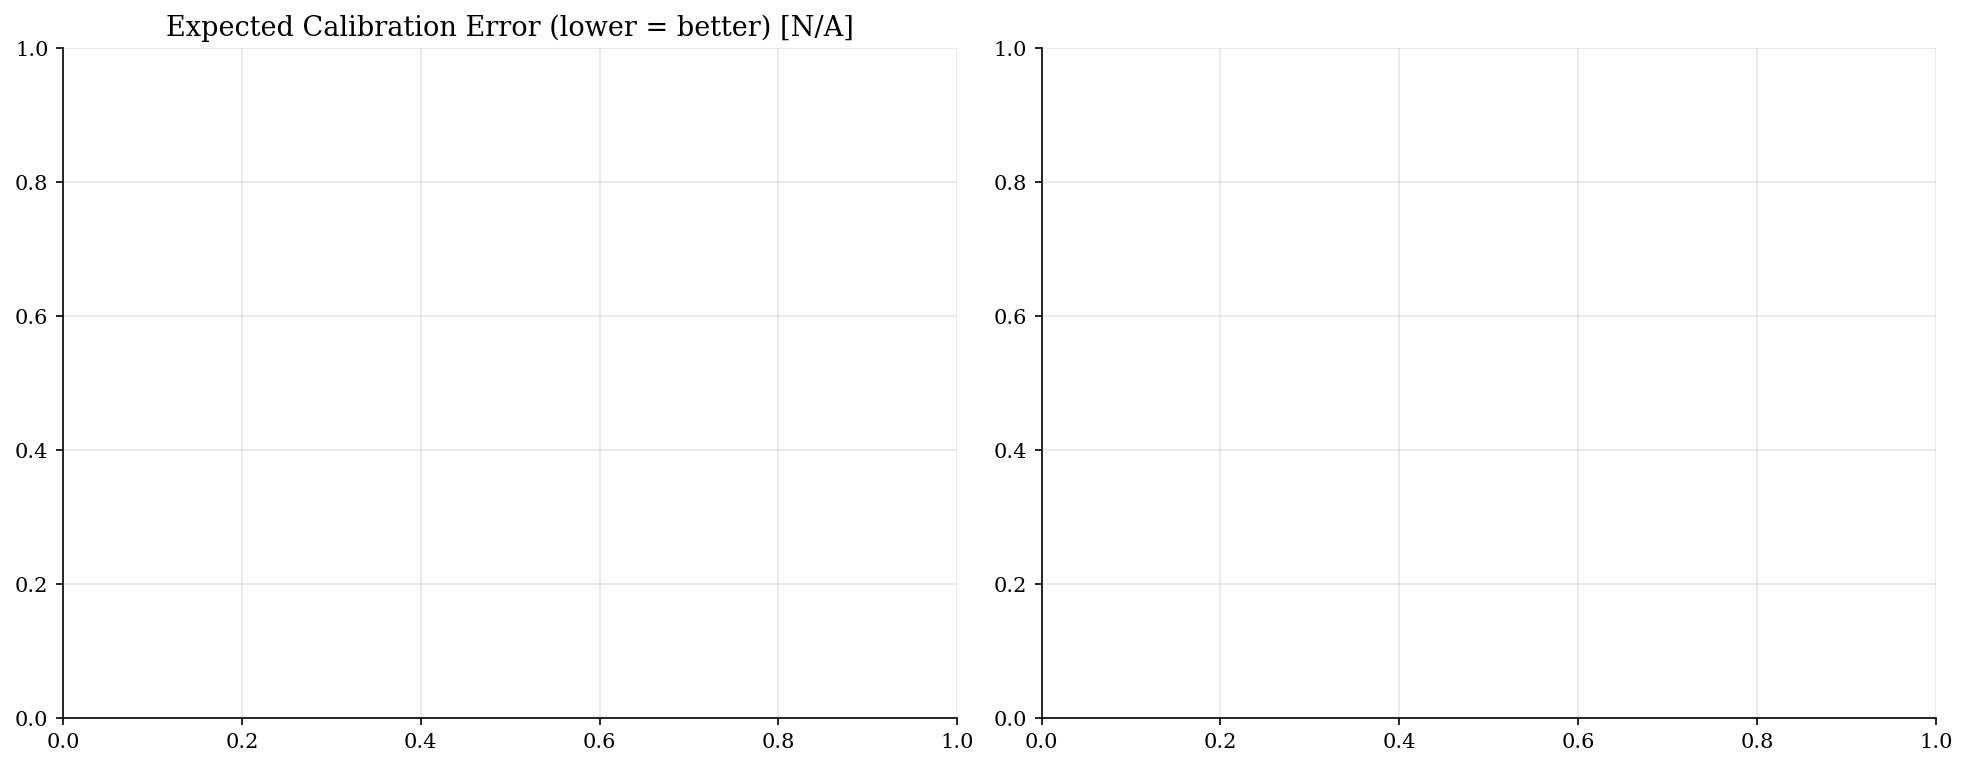

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
grouped_bar(master, 'final_ece', 'Expected Calibration Error (lower = better)', axes[0])
if 'final_ece' in master and 'best_accuracy' in master:
    for _, row in master.iterrows():
        if pd.isna(row.get('final_ece')) or pd.isna(row.get('best_accuracy')): continue
        axes[1].scatter(row['best_accuracy'], row['final_ece'],
                        color=C_DS.get(row['dataset'],'gray'),
                        marker=M_CLIENT.get(row['num_clients'],'o'), s=80, zorder=5)
    axes[1].set_xlabel('Best Accuracy'); axes[1].set_ylabel('Final ECE')
    axes[1].set_title('ECE vs. Accuracy', fontweight='bold')
    axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
savefig('05_calibration')
plt.show()


---
## § 8 — Per-class F1 Heatmaps (final round)

In [27]:
for ds in DATASETS:
    data = {}
    for nc in CLIENT_COUNTS:
        df = perclass_dfs.get((ds,nc))
        if df is None or df.empty: continue
        sub = df[df['round']==df['round'].max()].set_index('class_name')['f1']
        data[f'{nc}c'] = sub
    if not data: print(f'No per-class data for {ds}'); continue
    heat = pd.DataFrame(data).T.fillna(0).reindex(sorted(pd.DataFrame(data).index), axis=1)
    fig, ax = plt.subplots(figsize=(max(6, 1.4*len(heat.columns)), 2.8))
    sns.heatmap(heat, ax=ax, annot=True, fmt='.3f', cmap='Blues', vmin=0, vmax=1,
                linewidths=0.5, linecolor='white', annot_kws={'size':9},
                cbar_kws={'label':'F1','shrink':0.8})
    ax.set_title(f'{ds.replace("_"," ").title()} — Per-class F1 (final round)',
                 fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    savefig(f'06_perclass_f1_{ds}')
    plt.show()


No per-class data for brain_tumor_mri
No per-class data for colon_cancer_or_pathology
No per-class data for covid


---
## § 9 — Confusion Matrices (final round, recall-normalized)

In [28]:
for ds in DATASETS:
    cms, cnames = {}, []
    for nc in CLIENT_COUNTS:
        recs = evals.get((ds,nc), [])
        if not recs: continue
        cm_raw = recs[-1].get('confusion_matrix')
        if cm_raw is None: continue
        cm = np.array(cm_raw, float)
        rs = cm.sum(1, keepdims=True); rs[rs==0] = 1
        cms[nc] = cm / rs
        if not cnames:
            cnames = list(recs[-1].get('per_class',{}).keys()) or [str(i) for i in range(cm.shape[0])]
    if not cms: print(f'No confusion matrices for {ds}'); continue

    ncls = max(c.shape[0] for c in cms.values())
    fig, axes = plt.subplots(1, len(cms),
                             figsize=(3.8*ncls/4*len(cms)+0.5, 3.2*ncls/4+0.5),
                             squeeze=False)
    fig.suptitle(f'{ds.replace("_"," ").title()} — Confusion Matrices', fontweight='bold')
    for ci, (nc, cm_norm) in enumerate(sorted(cms.items())):
        ax = axes[0,ci]
        cn = cnames[:cm_norm.shape[0]]
        sns.heatmap(cm_norm, ax=ax, annot=True, fmt='.2f', cmap='Blues',
                    vmin=0, vmax=1, xticklabels=cn, yticklabels=cn,
                    linewidths=0.4, linecolor='white', annot_kws={'size':8},
                    cbar=(ci==len(cms)-1))
        ax.set_title(f'{nc} clients', fontweight='bold')
        ax.set_xlabel('Predicted'); ax.set_ylabel('True' if ci==0 else '')
        ax.tick_params(axis='x', rotation=35, labelsize=8)
        ax.tick_params(axis='y', rotation=0,  labelsize=8)
    savefig(f'07_confusion_{ds}')
    plt.show()


No confusion matrices for brain_tumor_mri
No confusion matrices for colon_cancer_or_pathology
No confusion matrices for covid


---
## § 10 — Client Class Distribution

In [29]:
for ds in DATASETS:
    # Key is 'client_class_distributions' (list of dicts, one per client)
    s = next((ds_sums[(ds,nc)] for nc in CLIENT_COUNTS
              if (ds,nc) in ds_sums and ds_sums[(ds,nc)].get('partitioning',{}).get('client_class_distributions')), None)
    if not s: print(f'No distribution data for {ds}'); continue
    raw = s['partitioning']['client_class_distributions']
    ccd = pd.DataFrame(raw).fillna(0).astype(int)
    ccd.index = [f'Client {i}' for i in range(len(ccd))]
    fig, axes = plt.subplots(1, 2, figsize=(13, max(3.5, 0.6*len(ccd))))
    fig.suptitle(f'{ds.replace("_"," ").title()} — Client Class Distribution', fontweight='bold')
    ccd.plot(kind='bar', stacked=True, ax=axes[0], colormap='tab10', edgecolor='white', lw=0.3)
    axes[0].set_title('Sample counts'); axes[0].set_xlabel('Client')
    axes[0].tick_params(axis='x', rotation=0)
    axes[0].legend(title='Class', fontsize=8, bbox_to_anchor=(1.01,1))
    (ccd.div(ccd.sum(1), axis=0)).plot(kind='bar', stacked=True, ax=axes[1],
                                        colormap='tab10', edgecolor='white', lw=0.3, legend=False)
    axes[1].set_title('Class fraction'); axes[1].set_xlabel('Client')
    axes[1].tick_params(axis='x', rotation=0)
    axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
    savefig(f'08_client_dist_{ds}')
    plt.show()


No distribution data for brain_tumor_mri
No distribution data for colon_cancer_or_pathology
No distribution data for covid


---
## § 11 — Time Analysis

  Saved: 09_time_comparison.png


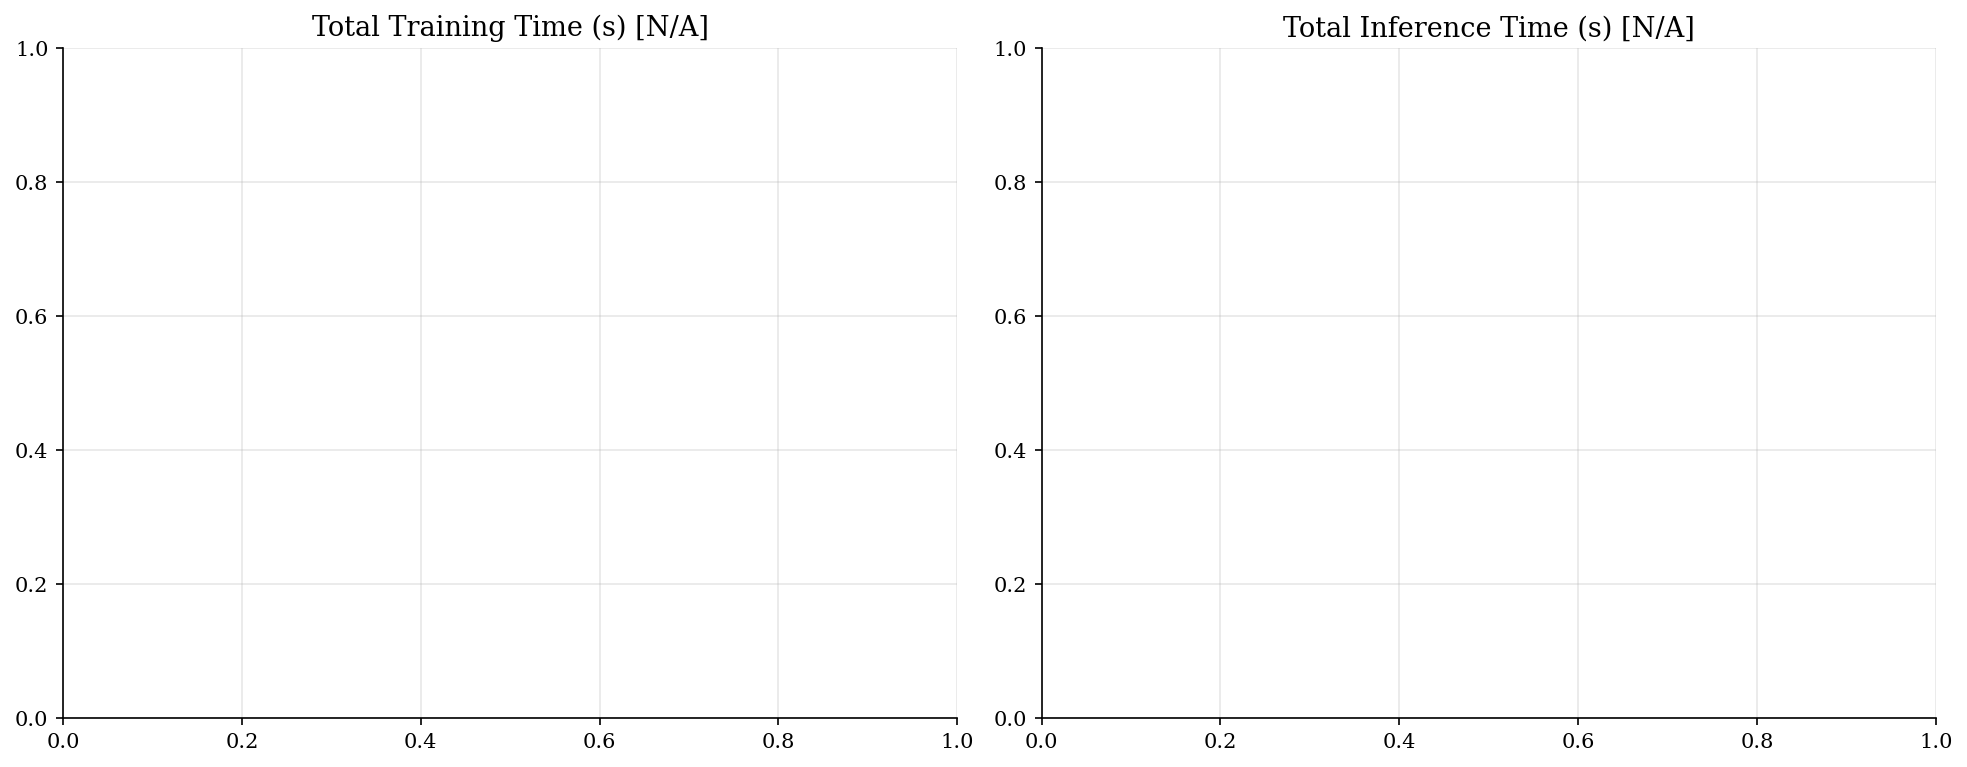

No SecAgg overhead data found — skipping SecAgg plots.


In [30]:
# Training & inference time
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
grouped_bar(master, 'total_training_time_sec',  'Total Training Time (s)',   axes[0])
grouped_bar(master, 'total_inference_time_sec', 'Total Inference Time (s)',  axes[1])
for ax in axes:
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
    ax.set_ylim(bottom=0)
savefig('09_time_comparison')
plt.show()

# SecAgg overhead timing
# secagg_overhead_sec is the simulated cost of SecAgg+ mask-generation and
# summation on actual model parameters. Real SecAgg+ protocol is disabled in
# run_simulation; this is an honest wall-clock estimate of the overhead.
if secagg_summary:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle('SecAgg+ Aggregation Overhead (Simulated)', fontweight='bold')

    sa_rows = [{'dataset': ds, 'num_clients': nc,
                'secagg_per_round_sec': info['per_round'],
                'secagg_total_sec':     info['total']}
               for (ds, nc), info in secagg_summary.items()]
    sa_df = pd.DataFrame(sa_rows)

    def _sa_bar(df, col, title, ax):
        tmp = df[['dataset','num_clients',col]].copy()
        tmp['num_clients'] = tmp['num_clients'].astype(str)+'c'
        piv = tmp.pivot(index='dataset', columns='num_clients', values=col)
        x = np.arange(len(piv)); w = 0.7/len(piv.columns)
        offs = np.linspace(-(len(piv.columns)-1)/2,(len(piv.columns)-1)/2,len(piv.columns))*w
        for nc_str, off in zip(piv.columns, offs):
            nc = int(nc_str[:-1])
            b = ax.bar(x+off, piv[nc_str], w, label=nc_str, color=C_CLIENT.get(nc,'gray'),
                       edgecolor='white', linewidth=0.5, zorder=3)
            ax.bar_label(b, fmt='%.3f', fontsize=7, padding=2)
        ax.set_title(title, fontweight='bold'); ax.set_xticks(x)
        ax.set_xticklabels([d.replace('_','\n') for d in piv.index], fontsize=8)
        ax.legend(title='Clients', fontsize=8); ax.set_axisbelow(True)
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
        ax.set_ylabel('Seconds'); ax.set_ylim(bottom=0)

    _sa_bar(sa_df, 'secagg_per_round_sec', 'SecAgg Overhead per Round (s)', axes[0])
    _sa_bar(sa_df, 'secagg_total_sec',     'SecAgg Total Overhead (s)',     axes[1])
    savefig('10_secagg_overhead_bars')
    plt.show()

    # Scaling line plot: overhead vs num_clients per dataset
    fig2, ax2 = plt.subplots(figsize=(7, 4))
    for ds in DATASETS:
        pts = [(nc, secagg_summary[(ds,nc)]['per_round'])
               for nc in CLIENT_COUNTS if (ds,nc) in secagg_summary]
        if not pts: continue
        xs, ys = zip(*sorted(pts))
        ax2.plot(xs, ys, marker='o', label=ds.replace('_',' '), color=C_DS.get(ds,'gray'))
    ax2.set_xlabel('Number of Clients')
    ax2.set_ylabel('SecAgg Overhead per Round (s)')
    ax2.set_title('SecAgg Overhead Scaling with Client Count', fontweight='bold')
    ax2.set_xticks(CLIENT_COUNTS); ax2.legend(fontsize=9)
    ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
    savefig('10_secagg_overhead_scaling')
    plt.show()
else:
    print('No SecAgg overhead data found — skipping SecAgg plots.')


---
## § 12 — Styled Summary Table

In [31]:
SHOW = ['dataset','num_clients','best_accuracy','final_balanced_accuracy',
        'best_macro_f1','final_precision_macro','final_recall_macro',
        'final_specificity_macro','final_roc_auc_macro','final_pr_auc_macro','final_ece']
avail = [c for c in SHOW if c in master.columns]
s = master[avail].rename(columns={
    'dataset':'Dataset','num_clients':'Clients',
    'best_accuracy':'Best Acc','final_balanced_accuracy':'Bal. Acc',
    'best_macro_f1':'Best F1','final_precision_macro':'Prec',
    'final_recall_macro':'Recall','final_specificity_macro':'Spec',
    'final_roc_auc_macro':'ROC-AUC','final_pr_auc_macro':'PR-AUC','final_ece':'ECE',
})
fcols = [c for c in s.columns if c not in ('Dataset','Clients')]
display(s.style
    .format({c:'{:.4f}' for c in fcols if c in s.columns}, na_rep='-')
    .background_gradient(cmap='Greens', subset=[c for c in fcols if c!='ECE' and c in s.columns],
                         vmin=0, vmax=1)
    .background_gradient(cmap='RdYlGn_r', subset=[c for c in ['ECE'] if c in s.columns],
                         vmin=0, vmax=0.3)
)


---
## § 13 — Download Figures

Zip `results/figures/` and download to your local machine.

In [32]:
import subprocess
subprocess.run(['zip', '-r', '/content/figures.zip', str(FIGURES_DIR)])

from google.colab import files
files.download('/content/figures.zip')
print('Download started.')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started.


---
## End

**Generated files in `results/`:**
```
master_summary.csv
final_comparison_table.csv
per_class_comparison.csv
figures/01_training_curves.png
figures/02_loss_decomposition.png
figures/03_accuracy_f1_balanced.png
figures/04_precision_recall_auc.png
figures/05_calibration.png
figures/06_perclass_f1_<ds>.png
figures/07_confusion_<ds>.png
figures/08_client_dist_<ds>.png
figures/09_time_comparison.png
```
Change `SAVE_FMT = 'pdf'` in § 1 for vector-format camera-ready output.